## Q3 Findings: Genre Popularity Over Time (1980-2015)

**Top 5 genres by aggregate sales:**
- Action, Sports, Shooter, Role-Playing, Platform

**Rise-and-fall patterns (2000s onwards):**
- **Action** dominates the modern era, peaking ~$130M around 2009-2010, 
  then declining
- **Sports** rises sharply through 2000s, peaks ~$110M around 2009, 
  declines steeply
- **Shooter** rises later than the others, peaks ~$85M around 2012-2013, 
  sustains longer through 2015

**Stable long-term patterns:**
- **Role-Playing** shows gradual, steady growth — the least volatile of 
  the top five, peaks ~$60M around 2007-2008
- **Platform** peaks earliest (~$45M around 2003) then declines steadily 
  through the modern era

**One interesting finding worth flagging:**
Shooter's peak arrives 3-4 years later than Action/Sports (2012-2013 vs 2009) 
and sustains longer. This differential timing raises questions the current 
dataset cannot resolve — franchise-specific trajectory analysis or digital-
sales inclusion would be needed to explain the divergence.

**Methodological notes:**
- 3-year rolling average applied to smooth single-year franchise spikes 
  and reveal underlying trajectories
- Genre popularity measured by summed Global_Sales, weighted toward 
  physically distributed titles
- Filtered to 1980-2015 to avoid the dataset cutoff artefact

**Follow-up questions this raises:**
- Do regional preferences differ significantly by genre? (JP vs Western markets)
- Which specific publishers dominate each genre?
- How does genre concentration compare across the same eras?

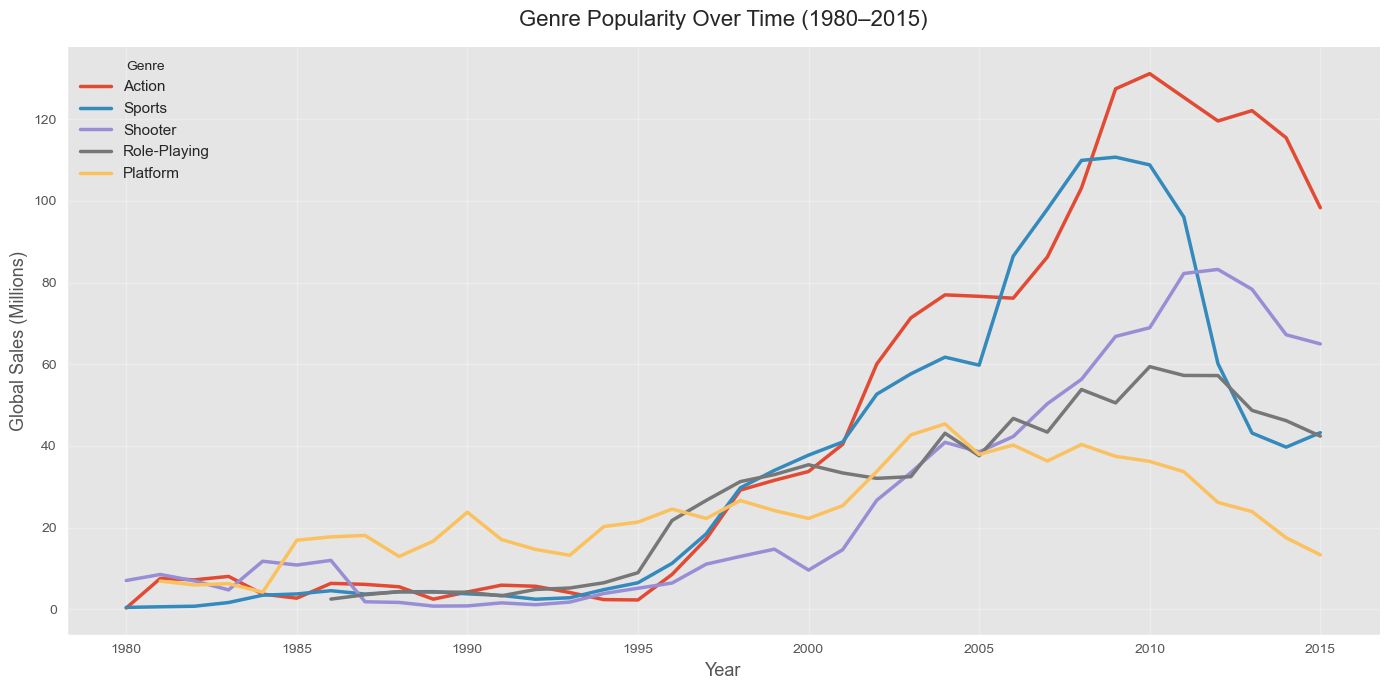

In [ ]:
# Step 3 - Clean Data & Chart Plotting.

import pandas as pd
import matplotlib.pyplot as plt

# 1. Drop missing years
df_years = df.dropna(subset=["Year"])

# 2. Aggregate global sales per genre per year
genre_year_sales = (
    df_years.groupby(["Year", "Genre"])["Global_Sales"]
            .sum()
            .reset_index()
)

# 3. Pivot into Year × Genre matrix
genre_pivot = genre_year_sales.pivot(
    index="Year",
    columns="Genre",
    values="Global_Sales"
)

# 4. Filter to reliable period (1980–2015)
genre_pivot = genre_pivot.loc[1980:2015]

# 5. Smooth with 3-year rolling average
genre_smooth = genre_pivot.rolling(window=3, min_periods=1).mean()

# 6. Select top 5 genres by total sales
top_genres = genre_pivot.sum().sort_values(ascending=False).head(5).index

# 7. Plot
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(14, 7))

for genre in top_genres:
    ax.plot(
        genre_smooth.index,
        genre_smooth[genre],
        label=genre,
        linewidth=2.5
    )

# 8. Styling
ax.set_title("Genre Popularity Over Time (1980–2015)", fontsize=16, pad=15)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Global Sales (Millions)", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha=0.3)
ax.legend(title="Genre", fontsize=11)

plt.tight_layout()

# 9. Save output
plt.savefig("outputs/q3_genre_popularity_over_time.png", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
# Step 2 - Key Design Decisions.

# Decision 1 - How many genres to plot?

# Choice: Top 5 genres by total global sales.
# This keeps the chart readable while still showing the major industry trends.

# Decision 2 - Raw values or rolling average?

# Choice: 3‑year rolling average.
# This reveals the true shape of each genre’s lifecycle.

# Decision 3 - Handle the post‑2015 artefact (similar to Question 2. (11-video-games-sales-learning.ipynb))

# Choice: Filter to 1980–2015 only.
# This keeps the chart clean and avoids misleading cliff effects.

# All Key Design Decisions Complete.

In [1]:
# Step 1 - Load & Inspect Dataset.

import pandas as pd
from pathlib import Path

SCRIPT_DIR = Path().resolve()
df = pd.read_csv(SCRIPT_DIR / "data" / "vgsales.csv")
df.columns = df.columns.str.strip()

# Standard inspection
df.shape
df.columns.tolist()
df.dtypes
df.head()
df["Publisher"].nunique()
df["Publisher"].value_counts().head(10)
df["Year"].min(), df["Year"].max()
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64